# This notebook is for surveillance path generation verion 7
# The AABB was developed by JJJ.
# The objective of this notebook is to develop Multiple-OBB algorithm to generate the surveillance path.

In [157]:
# Library
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Optional, Union, Dict
import time

@dataclass
class MinOnlyBounds:
    wmin: float = 10.0; hmin: float = 10.0


In [158]:
# vis.py
def generate_region(shape: str,
                    nx: int = 20,
                    ny: int = 20,
                    **kwargs) -> Tuple[int, int, List[int]]:
    """
    Generate a grid region and return (nx, ny, obs_pos).
    Shapes:
      - "rectangle": central open rectangle; rest obstacles
          kwargs: rect_w (int), rect_h (int), margin_x (int), margin_y (int)
      - "l": L-shaped open area; rest obstacles
          kwargs: vx0,vx1,vy0,vy1 (vertical leg), hx0,hx1,hy0,hy1 (horizontal leg)
      - "y": Y-shaped open area; rest obstacles
          kwargs: cx, cy (center), stem_h, arm_len, arm_thick, stem_thick, slope (float)
      - "random": random organic open blob via drunkard walk (+ optional dilation)
          kwargs: steps (int), seeds (int), jitter_prob (float), seed (int),
                  thicken_iters (int), thicken_neighbors ({"4","8"})
    """
    shape = shape.lower()
    open_mask = np.zeros((ny, nx), dtype=bool)  # False = obstacle, True = open

    if shape == "rectangle":
        rect_w  = kwargs.get("rect_w", max(4, nx // 2))
        rect_h  = kwargs.get("rect_h", max(4, ny // 2))
        margin_x = kwargs.get("margin_x", (nx - rect_w) // 2)
        margin_y = kwargs.get("margin_y", (ny - rect_h) // 2)
        x0 = np.clip(margin_x, 0, nx-1); y0 = np.clip(margin_y, 0, ny-1)
        x1 = np.clip(x0 + rect_w - 1, 0, nx-1)
        y1 = np.clip(y0 + rect_h - 1, 0, ny-1)
        open_mask[y0:y1+1, x0:x1+1] = True

    elif shape == "l":
        # --- Bigger, ratio-based defaults (targeting ~70–85% open when nx=ny=100) ---
        # vertical leg thickness & span
        v_w   = kwargs.get("v_w",   max(20, int(round(0.24 * nx))))
        v_x0  = kwargs.get("v_x0",  int(round(0.20 * nx)))
        v_y0  = kwargs.get("v_y0",  int(round(0.10 * ny)))
        v_y1  = kwargs.get("v_y1",  int(round(0.90 * ny)))
        # horizontal leg thickness & span
        h_h   = kwargs.get("h_h",   max(20, int(round(0.24 * ny))))
        h_y1  = kwargs.get("h_y1",  int(round(0.70 * ny)))  # bottom of horizontal band
        h_y0  = kwargs.get("h_y0",  max(0, h_y1 - h_h))
        h_x0  = kwargs.get("h_x0",  v_x0 + v_w)
        h_x1  = kwargs.get("h_x1",  int(round(0.92 * nx)))

        vx0, vx1 = np.clip(sorted([v_x0, v_x0 + v_w - 1]), 0, nx-1)
        vy0, vy1 = np.clip(sorted([v_y0, v_y1]),            0, ny-1)
        hx0, hx1 = np.clip(sorted([h_x0, h_x1]),            0, nx-1)
        hy0, hy1 = np.clip(sorted([h_y0, h_y1]),            0, ny-1)

        open_mask[vy0:vy1+1, vx0:vx1+1] = True
        open_mask[hy0:hy1+1, hx0:hx1+1] = True

        # kwargs 호환(기존 사용하던 vx0~hy1 직접 지정도 지원)
        for k, v in dict(vx0=kwargs.get("vx0"), vx1=kwargs.get("vx1"),
                         vy0=kwargs.get("vy0"), vy1=kwargs.get("vy1"),
                         hx0=kwargs.get("hx0"), hx1=kwargs.get("hx1"),
                         hy0=kwargs.get("hy0"), hy1=kwargs.get("hy1")).items():
            if v is not None:
                # 사용자가 지정하면 위 설정을 덮어쓰고 다시 채움
                locals()[k] = int(np.clip(v, 0, nx-1 if k.endswith(('x0','x1')) else ny-1))
        # (사용자가 직접 좌표를 모두 넣었을 경우) 다시 그리기
        # (이미 True로 칠했더라도 재칠해도 무방)
        # open_mask[vy0:vy1+1, vx0:vx1+1] = True
        # open_mask[hy0:hy1+1, hx0:hx1+1] = True

    elif shape == "y":
        # --- Bigger Y: thicker stem & longer arms by ratios ---
        cx = kwargs.get("cx", nx//2)
        cy = kwargs.get("cy", ny//2)
        stem_h     = kwargs.get("stem_h",     max(8, int(round(0.38 * ny))))
        stem_thick = kwargs.get("stem_thick", max(2, int(round(0.30 * nx))))
        arm_len    = kwargs.get("arm_len",    max(6, int(round(0.48 * min(nx, ny)))))
        arm_thick  = kwargs.get("arm_thick",  max(2, int(round(0.30 * nx))))
        slope      = kwargs.get("slope", 0.6)

        yy, xx = np.mgrid[0:ny, 0:nx]
        # Vertical stem (upwards from center)
        stem = (np.abs(xx - cx) <= stem_thick//2) & (yy >= cy) & (yy <= min(ny-1, cy + stem_h))
        # Arms (up-left / up-right from cy)
        band = int(round(0.02 * ny))
        armL = (yy <= cy + band) & (yy >= max(0, cy - arm_len)) & (np.abs((yy - cy) + slope*(xx - cx)) <= arm_thick)
        armR = (yy <= cy + band) & (yy >= max(0, cy - arm_len)) & (np.abs((yy - cy) - slope*(xx - cx)) <= arm_thick)

        open_mask |= stem | armL | armR

    elif shape == "random":
        # --- Larger organic blob: more steps + optional dilation(thickening) ---
        steps        = kwargs.get("steps", int(round(0.65 * nx * ny)))
        seeds        = kwargs.get("seeds", max(3, int(round(min(nx, ny) / 35))))
        jitter_prob  = kwargs.get("jitter_prob", 0.18)
        seed         = kwargs.get("seed", 7)
        thicken_iters = kwargs.get("thicken_iters", max(1, int(round(min(nx, ny)/50))))  # e.g., 2 when 100x100
        thicken_neighbors = kwargs.get("thicken_neighbors", "8")  # "4" or "8"

        rng = np.random.default_rng(seed)

        # Start seeds near center (spread slightly)
        centers = np.clip(np.array([
            [ny//2 + rng.integers(-ny//8, ny//8), nx//2 + rng.integers(-nx//8, nx//8)]
            for _ in range(seeds)
        ]), [0,0], [ny-1, nx-1])

        for (sy, sx) in centers:
            y, x = int(sy), int(sx)
            open_mask[y, x] = True
            for _ in range(max(1, steps // max(1, seeds))):
                dy, dx = rng.choice([-1, 0, 1]), rng.choice([-1, 0, 1])
                if rng.random() < jitter_prob:
                    dy = rng.choice([-1, 1]); dx = rng.choice([-1, 1])
                y = int(np.clip(y + dy, 0, ny-1))
                x = int(np.clip(x + dx, 0, nx-1))
                open_mask[y, x] = True
                # occasional local thickening
                if rng.random() < 0.44:
                    y0, y1 = max(0, y-1), min(ny-1, y+1)
                    x0, x1 = max(0, x-1), min(nx-1, x+1)
                    open_mask[y0:y1+1, x0:x1+1] = True

        # light morphological thickening without external libs
        def _dilate(mask: np.ndarray, neighbors: str = "8") -> np.ndarray:
            g = mask.copy()
            # 4-neighbors
            g[1:, :]  |= mask[:-1, :]
            g[:-1, :] |= mask[1:, :]
            g[:, 1:]  |= mask[:, :-1]
            g[:, :-1] |= mask[:, 1:]
            if neighbors == "8":
                g[1:, 1:]   |= mask[:-1, :-1]
                g[1:, :-1]  |= mask[:-1, 1:]
                g[:-1, 1:]  |= mask[1:, :-1]
                g[:-1, :-1] |= mask[1:, 1:]
            return g

        for _ in range(thicken_iters):
            open_mask = _dilate(open_mask, neighbors=thicken_neighbors)

    else:
        raise ValueError(f"Unknown shape: {shape}. Use one of: rectangle, l, y, random")

    # Convert to obs_pos (row-major indices for obstacles = where open_mask is False)
    obs_pos: List[int] = [int(r * nx + c) for r in range(ny) for c in range(nx) if not open_mask[r, c]]
    return nx, ny, obs_pos

def plot_anchors(nx:int, ny:int, obs_pos:List[int], anchors:List[Tuple[int,int]], title:str="Anchors"):
    grid = np.ones((ny, nx), dtype=float)
    for idx in obs_pos:
        r, c = divmod(idx, nx)
        grid[r, c] = 0.0

    plt.figure(figsize=(6,6))
    plt.imshow(grid, cmap='RdYlBu', origin='lower', vmin=0, vmax=1, alpha=0.85)
    if anchors:
        ay = [a[0] for a in anchors]
        ax = [a[1] for a in anchors]
        plt.scatter(ax, ay, s=60, marker='o', edgecolors='k')
        for i, (r,c) in enumerate(anchors, 1):
            plt.text(c, r, str(i), ha='center', va='center', fontweight='bold')
    plt.xticks([]); plt.yticks([])
    plt.title(title)
    plt.show()

# --- (optional) quick viewer for rotated bboxes ---
def plot_rotated_bboxes(nx:int, ny:int, obs_pos:List[int], bboxes:List[Dict[str, float]], title:str=""):
    grid = np.ones((ny, nx), dtype=float)
    for idx in obs_pos:
        r, c = divmod(idx, nx)
        grid[r, c] = 0.0

    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(grid, cmap='RdYlBu', origin='lower', vmin=0, vmax=1, alpha=0.85)
    for i, rect in enumerate(bboxes, 1):
        x0, y0, w, h, th = rect["x0"], rect["y0"], rect["w"], rect["h"], rect["theta_deg"]
        patch = Rectangle((x0, y0), w, h, angle=th, fill=False, linewidth=2)
        ax.add_patch(patch)
        # 라벨은 중심 근사치(회전 반영 없이 w/2,h/2)로 배치
        ax.text(x0 + w*0.5, y0 + h*0.5, str(i), ha='center', va='center', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title)
    plt.show()

In [159]:
# state_helpers.py
def _obs_to_open_mask(nx:int, ny:int, obs_pos:List[int]) -> np.ndarray:
    open_mask = np.ones((ny, nx), dtype=bool)  # True=open, False=obstacle
    for idx in obs_pos:
        r, c = divmod(idx, nx)
        open_mask[r, c] = False
    return open_mask

def _auto_min_spacing(open_mask: np.ndarray, k: int) -> int:
    """오픈셀 면적과 점 개수로부터 대략적인 격자 최소 간격 추정."""
    open_cells = int(open_mask.sum())
    if k <= 1 or open_cells <= 1:
        return 1
    # 한 점이 차지하는 평균 면적의 루트 ≈ 간격
    spacing = int(np.sqrt(open_cells / k))
    return max(2, spacing)

def _farthest_point_sampling(open_mask: np.ndarray,
                             k: int,
                             min_spacing: Optional[int] = None,
                             seed: int = 7) -> List[Tuple[int,int]]:
    """오픈셀에서 farthest-point 방식으로 k개 샘플링 (격자 간격 제한 지원)."""
    ys, xs = np.where(open_mask)
    N = len(ys)
    if N == 0 or k <= 0:
        return []
    rng = np.random.default_rng(seed)

    if min_spacing is None:
        min_spacing = _auto_min_spacing(open_mask, k)

    pts = np.stack([ys, xs], axis=1)  # (N,2)
    # 시작점: 랜덤
    i0 = int(rng.integers(0, N))
    anchors = [tuple(pts[i0])]
    # 각 후보에 대해 "현재 선택된 앵커까지의 최소 제곱거리" 유지
    d2 = np.sum((pts - pts[i0])**2, axis=1)

    # helper: 간격 제약 검사
    def _ok_spacing(p, anchors_list, ms=min_spacing):
        py, px = p
        for (ay, ax) in anchors_list:
            if (py - ay)**2 + (px - ax)**2 < ms**2:
                return False
        return True

    # 루프: 가장 먼 점을 고르되, 간격 불만족이면 후보 제외 → 반복
    while len(anchors) < k:
        j = int(np.argmax(d2))
        if d2[j] < 0:  # 더 이상 유효 후보 없음
            break
        cand = tuple(pts[j])
        if _ok_spacing(cand, anchors):
            anchors.append(cand)
            # 거리 업데이트(최소 거리 유지)
            d2 = np.minimum(d2, np.sum((pts - pts[j])**2, axis=1))
        else:
            # 간격 불만족: 해당 후보 영구 제외
            d2[j] = -1.0

        # 후보가 모두 소진되면 간격을 조금씩 완화
        if (d2 > 0).sum() == 0 and len(anchors) < k:
            min_spacing = max(1, min_spacing - 1)
            # 간격 완화 후 거리배열 초기화/갱신
            d2[:] = np.inf
            for (ay, ax) in anchors:
                d2 = np.minimum(d2, np.sum((pts - np.array([ay, ax]))**2, axis=1))
            # 이미 간격 위반으로 제외했던 것들도 재검토되도록 음수는 0으로 리셋
            d2[d2 < 0] = 0.0

    return anchors[:k]

def sample_anchors_in_open_space(nx:int, ny:int, obs_pos:List[int],
                                 num_avs:int,
                                 min_spacing: Optional[int] = None,
                                 seed:int = 7) -> List[Tuple[int,int]]:
    """
    오픈 공간에서 num_avs개의 anchor를 골고루 분산시켜 반환.
    - min_spacing: 격자 단위 최소 간격(없으면 자동 추정)
    - 반환 형식: [(row, col), ...]
    """
    open_mask = _obs_to_open_mask(nx, ny, obs_pos)
    anchors = _farthest_point_sampling(open_mask, num_avs, min_spacing=min_spacing, seed=seed)
    return anchors

Number = Union[int, float]

def _broadcast_param(x: Union[Number, List[Number]], k: int) -> List[Number]:
    """스칼라 -> 길이 k 리스트 브로드캐스트."""
    if isinstance(x, (int, float)):
        return [x] * k
    assert len(x) == k, f"Length mismatch: expected {k}, got {len(x)}"
    return list(x)

def _rect_cover_mask(nx:int, ny:int, rect:Dict[str, float]) -> np.ndarray:
    """
    단일 회전 사각형에 의해 커버되는 셀(센터포인트 기준) 마스크 반환 (True=커버).
    rect: {'x0','y0','w','h','theta_deg'}, x0/y0는 좌측하단 기준점.
    """
    x0, y0, w, h, th = rect["x0"], rect["y0"], rect["w"], rect["h"], rect["theta_deg"]
    # 셀 중심 좌표 (x: 0.5..nx-0.5, y: 0.5..ny-0.5)
    xs = np.arange(nx) + 0.5
    ys = np.arange(ny) + 0.5
    X, Y = np.meshgrid(xs, ys)  # shape (ny, nx)

    # 앵커 기준 좌표로 이동 후, -theta 회전(직교 정렬로 투영)
    rad = np.deg2rad(th)
    ct, st = np.cos(rad), np.sin(rad)
    Xp = X - x0
    Yp = Y - y0
    # inverse rotate by theta: [x'; y'] = R(-theta) [Xp; Yp]
    Xr =  ct * Xp + st * Yp
    Yr = -st * Xp + ct * Yp

    inside = (Xr >= 0.0) & (Xr <= w) & (Yr >= 0.0) & (Yr <= h)
    return inside

def coverage_ratio_open_space(
    nx:int, ny:int, obs_pos:List[int], bboxes:List[Dict[str, float]]
) -> Tuple[float, np.ndarray]:
    """
    박스 합집합이 오픈 스페이스에서 커버하는 비율(0~1) 반환.
    - 커버 판정은 셀 중심점이 박스 내부에 있는지로 계산.
    - 장애물 셀은 분모에서 제외.
    반환: (ratio, covered_union_mask)  # covered_union_mask는 전체 그리드 기준
    """
    open_mask = _obs_to_open_mask(nx, ny, obs_pos)
    if open_mask.sum() == 0:
        return 0.0, np.zeros_like(open_mask, dtype=bool)

    union_mask = np.zeros_like(open_mask, dtype=bool)
    for rect in bboxes:
        union_mask |= _rect_cover_mask(nx, ny, rect)

    covered_open = (union_mask & open_mask).sum()
    ratio = covered_open / float(open_mask.sum())
    return ratio, union_mask

def coverage_breakdown(nx:int, ny:int, obs_pos, bboxes):
    """
    오픈/비오픈 커버 면적과 비율을 한 번에 계산.
    반환 dict:
      - open_ratio:      (오픈 영역 중 커버된 비율)
      - nonopen_ratio:   (비오픈(장애물/경계 밖 아님) 중 커버된 비율; 'grid' 정규화)
      - nonopen_on_cov:  (커버된 셀 중 비오픈 비율; 'covered' 정규화)
      - areas: dict(covered_open, covered_nonopen, total_open, total_nonopen, total_covered)
      - union_mask: 커버 union (시각화에 사용 가능)
    """
    open_mask = _obs_to_open_mask(nx, ny, obs_pos)
    ratio_open, union_mask = coverage_ratio_open_space(nx, ny, obs_pos, bboxes)  # 이미 구현됨

    covered = union_mask.sum()
    total_open = int(open_mask.sum())
    total_nonopen = nx*ny - total_open

    covered_open = int((union_mask & open_mask).sum())
    covered_nonopen = int((union_mask & (~open_mask)).sum())

    # 정규화 방식 2종: grid 전체 기준 vs. "커버된 셀" 기준
    nonopen_ratio_grid = (covered_nonopen / total_nonopen) if total_nonopen > 0 else 0.0
    nonopen_ratio_on_cov = (covered_nonopen / covered) if covered > 0 else 0.0

    return {
        "open_ratio": ratio_open,
        "nonopen_ratio": nonopen_ratio_grid,
        "nonopen_on_cov": nonopen_ratio_on_cov,
        "areas": {
            "covered_open": covered_open,
            "covered_nonopen": covered_nonopen,
            "total_open": total_open,
            "total_nonopen": total_nonopen,
            "total_covered": covered
        },
        "union_mask": union_mask
    }

def overlap_breakdown(nx:int, ny:int, obs_pos, bboxes):
    """
    겹침(둘 이상 박스가 덮은 셀) 비율을 계산.
    반환:
      - overlap_on_covered:  겹침셀 / (커버된 전체셀)         ← 커버 중 낭비 비율
      - overlap_on_open:     (겹침∧오픈) / (커버∧오픈)        ← 오픈 영역 내 겹침 비율
      - areas: dict(covered, overlap, covered_open, overlap_open)
      - union_mask: 커버 합집합 (시각화 용)
    """
    open_mask = _obs_to_open_mask(nx, ny, obs_pos)
    ny_, nx_ = ny, nx
    if not bboxes:
        return {
            "overlap_on_covered": 0.0, "overlap_on_open": 0.0,
            "areas": {"covered": 0, "overlap": 0, "covered_open": 0, "overlap_open": 0},
            "union_mask": np.zeros((ny_, nx_), dtype=bool),
        }

    counts = np.zeros((ny_, nx_), dtype=np.uint16)
    for rect in bboxes:
        counts += _rect_cover_mask(nx, ny, rect).astype(np.uint16)

    union_mask   = counts >= 1
    overlap_mask = counts >= 2

    covered         = int(union_mask.sum())
    overlap         = int(overlap_mask.sum())
    covered_open    = int((union_mask   & open_mask).sum())
    overlap_open    = int((overlap_mask & open_mask).sum())

    overlap_on_cov  = (overlap / covered)       if covered      > 0 else 0.0
    overlap_on_open = (overlap_open / covered_open) if covered_open > 0 else 0.0

    return {
        "overlap_on_covered": overlap_on_cov,
        "overlap_on_open": overlap_on_open,
        "areas": {
            "covered": covered,
            "overlap": overlap,
            "covered_open": covered_open,
            "overlap_open": overlap_open,
        },
        "union_mask": union_mask,
    }

def build_bboxes_from_anchors_ll(
    anchors: List[Tuple[int,int]],
    widths: Union[Number, List[Number]],
    heights: Union[Number, List[Number]],
    thetas_deg: Union[Number, List[Number]]
) -> List[Dict[str, float]]:
    """
    앵커(행,열)를 박스의 '좌측하단(lower-left)' 코너로 놓고 회전 사각형 정의.
    좌표계: x=열(col), y=행(row), y는 아래에서 위로 증가(plt.imshow(origin='lower')와 일치)
      - anchor = (r, c) -> (x0, y0) = (c, r)
      - width: +x 방향, height: +y 방향
      - theta_deg: CCW(+), anchor(좌측하단) 기준 회전
    반환: [{'x0','y0','w','h','theta_deg'}, ...]
    """
    k = len(anchors)
    W = _broadcast_param(widths, k)
    H = _broadcast_param(heights, k)
    T = _broadcast_param(thetas_deg, k)
    bboxes = []
    for (r, c), w, h, t in zip(anchors, W, H, T):
        bboxes.append({"x0": float(c), "y0": float(r), "w": float(w), "h": float(h), "theta_deg": float(t)})
    return bboxes

def make_state_ll(
    anchors: List[Tuple[int,int]],
    width: float,
    height: float,
    thetas_deg: Union[float, List[float], np.ndarray]
) -> Dict[str, np.ndarray]:
    """
    LL-anchor 기준 state:
      - xy: (N,2) with [row(y), col(x)] for each anchor
      - w, h: 모든 박스 공통 스칼라 (float)
      - theta: (N,) 각도(deg), 박스별 회전
    """
    A = np.array([[r, c] for (r, c) in anchors], dtype=float)        # (N,2) = [y, x]
    if isinstance(thetas_deg, (int, float)):
        theta = np.full(len(anchors), float(thetas_deg), dtype=float)
    else:
        theta = np.asarray(thetas_deg, dtype=float)
        assert theta.shape[0] == len(anchors), "len(thetas_deg) must equal num anchors"
    return {"xy": A, "w": float(width), "h": float(height), "theta": theta}

def bboxes_from_state_ll(state: Dict[str, np.ndarray]) -> List[Dict[str, float]]:
    """
    state(LL) -> 회전 사각형 리스트(dict)
    dict: {'x0','y0','w','h','theta_deg'}
    """
    xy = state["xy"]        # (N,2) [y, x]
    w  = float(state["w"])
    h  = float(state["h"])
    th = state["theta"]     # (N,)
    bboxes = []
    for i in range(xy.shape[0]):
        y0, x0 = xy[i, 0], xy[i, 1]       # LL-anchor: (row -> y0, col -> x0)
        bboxes.append({"x0": float(x0), "y0": float(y0), "w": w, "h": h, "theta_deg": float(th[i])})
    return bboxes

In [160]:
# neighbor.py
def _anchor_is_open(open_mask, y, x):
    ny, nx = open_mask.shape
    iy, ix = int(round(y)), int(round(x))
    if iy < 0 or iy >= ny or ix < 0 or ix >= nx:
        return False
    return open_mask[iy, ix]

def _try_move_anchor_once(state, i, dy, dx, nx, ny, open_mask, nxny_clip=True):
    """
    state: {"xy": (N,2)[y,x], "w": float, "h": float, "theta": (N,)}
    i번째 앵커를 (dy,dx)만큼 움직인 후보 state 반환. (불가하면 None)
    """
    s = {k: (v.copy() if isinstance(v, np.ndarray) else v) for k, v in state.items()}
    y, x = s["xy"][i]
    y2, x2 = y + dy, x + dx
    if nxny_clip:
        y2 = float(np.clip(y2, 0, ny-1))
        x2 = float(np.clip(x2, 0, nx-1))
    if not _anchor_is_open(open_mask, y2, x2):
        return None
    s["xy"][i, 0] = y2
    s["xy"][i, 1] = x2
    return s

def _get_min_wh(bounds):
    # MinOnlyBounds(wmin,hmin) 또는 (w,h) / dict(min_w,min_h) 호환
    if hasattr(bounds, "wmin") and hasattr(bounds, "hmin"):
        return float(bounds.wmin), float(bounds.hmin)
    if hasattr(bounds, "min_w") and hasattr(bounds, "min_h"):
        return float(bounds.min_w), float(bounds.min_h)
    if isinstance(bounds, (tuple, list)) and len(bounds) == 2:
        return float(bounds[0]), float(bounds[1])
    if isinstance(bounds, dict) and "min_w" in bounds and "min_h" in bounds:
        return float(bounds["min_w"]), float(bounds["min_h"])
    return 5.0, 5.0

def _try_resize_global_once(state, dw, dh, bounds, only_grow=True, max_w=None, max_h=None):
    """
    state의 전역 width/height를 (dw, dh)만큼 변경한 후보 반환 (개선 여지 없으면 None).
    - only_grow=True 이면 증가만 허용 (감소 금지)
    - bounds: 최소 크기 보장 (w>=wmin, h>=hmin)
    - max_w/max_h 주면 상한도 보장
    """
    s = {k: (v.copy() if hasattr(v, "copy") else v) for k, v in state.items()}
    wmin, hmin = _get_min_wh(bounds)

    new_w = s["w"] + float(dw)
    new_h = s["h"] + float(dh)

    if only_grow:
        new_w = max(new_w, s["w"])
        new_h = max(new_h, s["h"])

    new_w = max(new_w, wmin)
    new_h = max(new_h, hmin)

    if max_w is not None:
        new_w = min(new_w, float(max_w))
    if max_h is not None:
        new_h = min(new_h, float(max_h))

    # 변화가 없다면 후보 없음
    if abs(new_w - s["w"]) < 1e-9 and abs(new_h - s["h"]) < 1e-9:
        return None

    s["w"] = float(new_w)
    s["h"] = float(new_h)
    return s

def _try_rotate_once(state, i, dtheta_deg, wrap="360"):
    """
    i번째 박스의 회전을 dtheta_deg 만큼 변경한 후보 state 반환.
    wrap: "360" → [0,360)로 정규화 / "180" → [-90,90]로 정규화 / None → 무제한
    """
    s = {k: (v.copy() if hasattr(v, "copy") else v) for k, v in state.items()}
    s["theta"][i] = float(s["theta"][i] + float(dtheta_deg))

    if wrap == "360":
        # 0~360 범위로
        s["theta"][i] = s["theta"][i] % 360.0
    elif wrap == "180":
        # -90~90 범위로 (boustrophedon 등 180주기 문제에 유용)
        th = ((s["theta"][i] + 90.0) % 180.0) - 90.0
        s["theta"][i] = th
    # wrap=None 이면 그대로 둠

    return s

In [161]:
# energy.py
def energy_open_coverage_from_state(nx:int, ny:int, obs_pos, state: Dict[str, np.ndarray]) -> float:
    """
    E = 1 - coverage (추후 패널티 확장 예정)
    """
    bboxes = bboxes_from_state_ll(state)
    ratio, _ = coverage_ratio_open_space(nx, ny, obs_pos, bboxes)
    return 1.0 - ratio

def energy_open_vs_obstacle_from_state(
    nx:int, ny:int, obs_pos, state,
    lam: float = 1.0,
    penalty_norm: str = "covered",  # {"covered","grid"}
):
    """
    E = (1 - open_ratio) + lam * penalty
      - penalty_norm="covered": penalty = nonopen_on_cov  (권장)
      - penalty_norm="grid":    penalty = nonopen_ratio   (비오픈 전체 대비 비율)
    """
    bboxes = bboxes_from_state_ll(state)
    cb = coverage_breakdown(nx, ny, obs_pos, bboxes)

    if penalty_norm == "covered":
        penalty = cb["nonopen_on_cov"]
    elif penalty_norm == "grid":
        penalty = cb["nonopen_ratio"]
    else:
        raise ValueError("penalty_norm must be 'covered' or 'grid'")

    return (1.0 - cb["open_ratio"]) + lam * penalty

def energy_open_obs_overlap_from_state(
    nx:int, ny:int, obs_pos, state,
    lam_obs: float = 0.3,     # 비오픈(장애물) 커버 패널티 가중치
    lam_ov:  float = 0.2,     # 겹침 패널티 가중치 (소프트)
    norm_obs: str = "covered",  # {"covered","grid"}: 비오픈 패널티 정규화 방식
    norm_ov:  str = "open"      # {"covered","open"}: 겹침 패널티 정규화 방식
):
    """
    E = (1 - open_ratio) + lam_obs * penalty_nonopen + lam_ov * penalty_overlap
      - open_ratio: 오픈 영역 커버율 (↑ good)
      - penalty_nonopen:
          * "covered" -> nonopen_on_cov (커버된 셀 중 비오픈 비율, 권장)
          * "grid"    -> nonopen_ratio  (그리드 전체 대비 비오픈 커버 비율)
      - penalty_overlap:
          * "open"    -> overlap_on_open (오픈 내에서 겹친 비율, 권장)
          * "covered" -> overlap_on_covered (커버 전체 중 겹침 비율)
    """
    bboxes = bboxes_from_state_ll(state)

    # open / non-open
    cb = coverage_breakdown(nx, ny, obs_pos, bboxes)
    open_ratio = cb["open_ratio"]
    if norm_obs == "covered":
        p_nonopen = cb["nonopen_on_cov"]
    elif norm_obs == "grid":
        p_nonopen = cb["nonopen_ratio"]
    else:
        raise ValueError("norm_obs must be 'covered' or 'grid'")

    # overlap
    ob = overlap_breakdown(nx, ny, obs_pos, bboxes)
    if norm_ov == "open":
        p_overlap = ob["overlap_on_open"]
    elif norm_ov == "covered":
        p_overlap = ob["overlap_on_covered"]
    else:
        raise ValueError("norm_ov must be 'open' or 'covered'")

    return (1.0 - open_ratio) + lam_obs * p_nonopen + lam_ov * p_overlap



In [162]:
# === Simulated Annealing utilities (vanilla) ===
@dataclass
class SAConfig:
    # temperature
    T0: float = 1.0
    Tmin: float = 1e-3
    alpha: float = 0.98  # geometric cooling

    # neighbor probs
    p_move: float = 0.6
    p_rot:  float = 0.3
    p_size: float = 0.1

    # step maxima (will shrink with T)
    step_xy_max: int = 2
    step_th_max_deg: float = 10.0
    step_sz_max: int = 2

    # step decay exponents (T/T0)^gamma
    gamma_xy: float = 1.0
    gamma_th: float = 1.0
    gamma_sz: float = 1.0

    # allow shrink of w/h when T/T0 < ratio
    shrink_enable_ratio: float = 0.5

    # retry when neighbor invalid
    neighbor_retry: int = 8

    # SA loop sizes (기본 예산)
    outer_rounds: int = 30
    inner_loops:  int = 200

    # stall/reheat
    stall_rounds: int = 5
    reheats_max:  int = 1
    reheat_factor: float = 1.5

    seed: int = 7

def cool_geometric(T: float, alpha: float) -> float:
    return max(T * alpha, 1e-12)

def metropolis_accept(dE: float, T: float, rng: np.random.Generator) -> bool:
    if dE <= 0.0:
        return True
    if T <= 0.0:
        return False
    return rng.random() < np.exp(-dE / T)

def _copy_state(state):
    return {k: (v.copy() if hasattr(v, "copy") else v) for k, v in state.items()}

def propose_neighbor(state, nx, ny, open_mask, bounds,
                     max_w=None, max_h=None,
                     T: float = 1.0, T0: float = 1.0,
                     cfg: SAConfig = None,
                     rng: np.random.Generator = None) -> Tuple[Optional[dict], Optional[dict]]:
    """
    Return (cand_state, meta) or (None, None).
    - move: 임의 앵커 1개 (±Δy, ±Δx) * step_xy (open cell 강제)
    - rotate: 임의 앵커 1개 ±Δθ
    - size: (dw,0)/(0,dh)/(dw,dh) 중 하나, 낮은 T에서 shrink 허용
    """
    assert cfg is not None
    rng = rng or np.random.default_rng(cfg.seed)

    ratio = max(1e-9, min(1.0, T / T0))
    step_xy = max(1, int(round(cfg.step_xy_max * (ratio**cfg.gamma_xy))))
    step_th = max(2.0, float(cfg.step_th_max_deg * (ratio**cfg.gamma_th)))
    step_sz = max(1, int(round(cfg.step_sz_max * (ratio**cfg.gamma_sz))))

    probs = np.array([cfg.p_move, cfg.p_rot, cfg.p_size], dtype=float)
    probs = probs / probs.sum()
    dirs = [(1,0),(-1,0),(0,1),(0,-1)]

    for _ in range(cfg.neighbor_retry):
        op = rng.choice([0,1,2], p=probs)  # 0:move, 1:rotate, 2:size

        if op == 0:  # move
            cand = _copy_state(state)
            i = int(rng.integers(0, cand["xy"].shape[0]))
            dy, dx = dirs[int(rng.integers(0, len(dirs)))]
            ok = True
            for _step in range(step_xy):
                nxt = _try_move_anchor_once(cand, i, dy, dx, nx, ny, open_mask, nxny_clip=True)
                if nxt is None:
                    ok = False
                    break
                cand = nxt
            if ok:
                return cand, {"op":"move", "idx":i, "dy":dy*step_xy, "dx":dx*step_xy}

        elif op == 1:  # rotate
            cand = _copy_state(state)
            i = int(rng.integers(0, cand["xy"].shape[0]))
            dth = (+step_th) if rng.random() < 0.5 else (-step_th)
            cand = _try_rotate_once(cand, i, dth, wrap="360")
            return cand, {"op":"rotate", "idx":i, "dth":dth}

        else:  # size
            cand = _copy_state(state)
            allow_shrink = (ratio < cfg.shrink_enable_ratio)
            # 감소 확률은 30% 정도로 보수적
            sign_w = (1 if (not allow_shrink or rng.random()<0.7) else -1)
            sign_h = (1 if (not allow_shrink or rng.random()<0.7) else -1)
            mode = rng.choice(["w","h","both"], p=[0.4, 0.4, 0.2])
            dw = sign_w * step_sz if mode in ("w","both") else 0
            dh = sign_h * step_sz if mode in ("h","both") else 0
            if dw == 0 and dh == 0:
                continue
            nxt = _try_resize_global_once(
                cand, dw, dh, bounds,
                only_grow=not allow_shrink,
                max_w=max_w, max_h=max_h
            )
            if nxt is not None:
                cand = nxt
                return cand, {"op":"size", "dw":dw, "dh":dh, "mode":mode, "shrink":allow_shrink}

    return None, None


In [163]:
def anneal(nx:int, ny:int, obs_pos, state0, bounds,
           lam_obs:float=0.3, lam_ov:float=0.5,
           cfg: SAConfig = None,
           time_limit: float = 10.0,
           max_w=None, max_h=None,
           rng_seed: int = 7):
    """
    Full SA loop (vanilla).
    Returns: best_state, best_E, stats(dict)
    """
    assert cfg is not None
    rng = np.random.default_rng(rng_seed)
    open_mask = _obs_to_open_mask(nx, ny, obs_pos)

    state = _copy_state(state0)
    E = energy_open_obs_overlap_from_state(nx, ny, obs_pos, state,
                                           lam_obs=lam_obs, lam_ov=lam_ov,
                                           norm_obs="covered", norm_ov="open")
    best_state = _copy_state(state)
    best_E = E

    T = cfg.T0
    start = time.time()
    timeup = False
    stall = 0
    reheats = 0

    # 카운트/로그
    stats = dict(
        proposed=0, accepted=0,
        move=0, move_acc=0,
        rotate=0, rotate_acc=0,
        size=0, size_acc=0,
        rounds=[]
    )

    for r in range(cfg.outer_rounds):
        round_prop = 0
        round_acc  = 0
        round_best_E = E

        # FIX: 라운드별 진단 카운터 초기화
        round_better = 0
        round_worse = 0
        round_worse_sum = 0.0

        for _ in range(cfg.inner_loops):
            if (time.time() - start) > time_limit:
                timeup = True
                break

            cand, meta = propose_neighbor(
                state, nx, ny, open_mask, bounds,
                max_w=max_w, max_h=max_h,
                T=T, T0=cfg.T0, cfg=cfg, rng=rng
            )
            if cand is None:
                continue

            stats["proposed"] += 1
            round_prop += 1
            stats[meta["op"]] += 1

            Ec = energy_open_obs_overlap_from_state(nx, ny, obs_pos, cand,
                                                    lam_obs=lam_obs, lam_ov=lam_ov,
                                                    norm_obs="covered", norm_ov="open")
            dE = float(Ec - E)

            tau_w = 0.01   # 0.2~0.5 사이로 시작해서 로그 보며 튠
            T_eff = T * (tau_w if dE > 0.0 else 1.0) # 결과 악화됐을 때도 수용하는 비율 조정
            if metropolis_accept(dE, T_eff, rng):
                if dE <= 0.0:
                    round_better += 1
                else:
                    round_worse  += 1
                    round_worse_sum += dE
                state, E = cand, Ec
                stats["accepted"] += 1
                round_acc += 1
                stats[meta["op"]+"_acc"] += 1
                

                if E < best_E - 1e-12:
                    best_E = E
                    best_state = _copy_state(state)

        cov = 1.0 - E
        acc_rate = (round_acc / round_prop) if round_prop > 0 else 0.0
        worse_ratio   = (round_worse / round_acc) if round_acc > 0 else 0.0
        avg_worse_dE  = (round_worse_sum / round_worse) if round_worse > 0 else 0.0
        print(
            f"[SA] round={r+1}/{cfg.outer_rounds}  "
            f"T={T:.4f}  score={cov:.4f}  "
            f"acc={round_acc}/{round_prop}({acc_rate:.2%})  "
            f"worse_acc={round_worse}/{round_acc}({worse_ratio:.2%})  "
            f"avg_worse_dE={avg_worse_dE:.4f}"
        )

        # 누적 stats 업데이트
        stats.setdefault("accepted_better", 0)
        stats.setdefault("accepted_worse", 0)
        stats.setdefault("sum_worse_dE", 0.0)
        stats["accepted_better"] += round_better
        stats["accepted_worse"]  += round_worse
        stats["sum_worse_dE"]    += round_worse_sum

        stats["rounds"].append(dict(
            T=T, coverage=cov,
            proposed=round_prop, accepted=round_acc, acc_rate=acc_rate,
            accepted_better=round_better, accepted_worse=round_worse,
            avg_worse_dE=avg_worse_dE
        ))

        # stall check (이 라운드 시작 대비 개선 여부)
        if E < round_best_E - 1e-12:
            stall = 0
        else:
            stall += 1

        # 냉각
        T = cool_geometric(T, cfg.alpha)

        # 조기 종료/재가열
        if T < cfg.Tmin:
            print("[SA] reached Tmin")
            break
        if timeup:
            print("[SA] time limit reached")
            break
        if stall >= cfg.stall_rounds and reheats < cfg.reheats_max:
            reheats += 1
            stall = 0
            T = min(cfg.T0, T * cfg.reheat_factor)
            print(f"[SA] reheating #{reheats}: T -> {T:.4f}")

    return best_state, best_E, stats

In [164]:
def greedy_refine(nx, ny, obs_pos, state_init, bounds,
                  lam_obs, lam_ov,
                  num_avs,
                  rot_step=5.0, size_step=1.0,
                  max_w=None, max_h=None,
                  patience=50, greedy_time_limit=3.0,
                  full_rot_every=5, rotate_load_cap=10, rotate_sample_frac=0.5):
    """
    기존 그리디 탐색을 짧게 돌려 초기 해를 만드는 함수.
    반환: (state_g, E_g, elapsed_s)
    """
    import time
    # 필요: _obs_to_open_mask / energy_open_obs_overlap_from_state / _try_* 함수들
    open_mask = _obs_to_open_mask(nx, ny, obs_pos)
    dirs = [(1,0), (-1,0), (0,1), (0,-1)]

    # 상태/에너지 초기화
    state = {k: (v.copy() if hasattr(v, "copy") else v) for k, v in state_init.items()}
    E = energy_open_obs_overlap_from_state(
        nx, ny, obs_pos, state,
        lam_obs=lam_obs, lam_ov=lam_ov,
        norm_obs="covered", norm_ov="open"
    )

    max_iter = 2000
    no_improve = 0
    start_t = time.time()

    for it in range(max_iter):
        improved = False

        # Translation (셔플 + 그리디)
        order = np.random.permutation(num_avs)
        moved = []
        for idx in order:
            best_state = None
            best_E = E
            for dy, dx in dirs:
                cand = _try_move_anchor_once(state, idx, dy, dx, nx, ny, open_mask)
                if cand is None:
                    continue
                Ec = energy_open_obs_overlap_from_state(
                    nx, ny, obs_pos, cand,
                    lam_obs=lam_obs, lam_ov=lam_ov,
                    norm_obs="covered", norm_ov="open"
                )
                if Ec < best_E - 1e-9:
                    best_E = Ec
                    best_state = cand
            if best_state is not None:
                state = best_state
                E = best_E
                moved.append(int(idx))
                improved = True

        # Rotation: 이번 iteration에서 "안 움직인" 앵커만 회전 시도 (+옵션 적용)
        all_idx   = set(range(num_avs))
        to_rotate = list(all_idx - set(moved))

        if full_rot_every and ((it + 1) % full_rot_every == 0):
            to_rotate = list(range(num_avs))

        if not to_rotate:
            to_rotate = [int(order[-1])]

        L = len(to_rotate)
        if L > 1 and (rotate_load_cap is not None or rotate_sample_frac < 1.0):
            k_frac = int(np.ceil(L * rotate_sample_frac)) if rotate_sample_frac < 1.0 else L
            k_cap  = rotate_load_cap if rotate_load_cap is not None else L
            k = max(1, min(L, k_frac, k_cap))
            if k < L:
                to_rotate = list(np.random.choice(to_rotate, size=k, replace=False))

        to_rotate = list(np.random.permutation(to_rotate))

        for idx_rot in to_rotate:
            local_best_state = None
            local_best_E = E
            for dth in (rot_step, -rot_step):
                cand = _try_rotate_once(state, idx_rot, dth, wrap="360")
                Ec = energy_open_obs_overlap_from_state(
                    nx, ny, obs_pos, cand,
                    lam_obs=lam_obs, lam_ov=lam_ov,
                    norm_obs="covered", norm_ov="open"
                )
                if Ec < local_best_E - 1e-9:
                    local_best_E = Ec
                    local_best_state = cand
            if local_best_state is not None:
                state = local_best_state
                E = local_best_E
                improved = True

        # 전역 사이즈 증가 (세 후보 중 최선 1회)
        best_state_size = None
        best_E_size = E
        for dw, dh in [(size_step, 0.0), (0.0, size_step), (size_step, size_step)]:
            cand = _try_resize_global_once(state, dw, dh, bounds,
                                           only_grow=True, max_w=max_w, max_h=max_h)
            if cand is None:
                continue
            Ec = energy_open_obs_overlap_from_state(
                nx, ny, obs_pos, cand,
                lam_obs=lam_obs, lam_ov=lam_ov,
                norm_obs="covered", norm_ov="open"
            )
            if Ec < best_E_size - 1e-9:
                best_E_size = Ec
                best_state_size = cand
        if best_state_size is not None:
            state = best_state_size
            E = best_E_size
            improved = True

        # 중단 조건
        no_improve = 0 if improved else (no_improve + 1)
        if no_improve >= patience:
            break
        if time.time() - start_t > greedy_time_limit:
            break

    elapsed_s = time.time() - start_t
    return state, E, elapsed_s


[init] score =0.0064
[warm-start: greedy] score=0.8903, elapsed=3.08s
[SA] round=1/90  T=0.9000  score=0.8803  acc=84/200(42.00%)  worse_acc=43/84(51.19%)  avg_worse_dE=0.0064
[SA] round=2/90  T=0.8820  score=0.8509  acc=105/200(52.50%)  worse_acc=53/105(50.48%)  avg_worse_dE=0.0070
[SA] round=3/90  T=0.8644  score=0.7962  acc=94/200(47.00%)  worse_acc=47/94(50.00%)  avg_worse_dE=0.0078
[SA] round=4/90  T=0.8471  score=0.7517  acc=99/200(49.50%)  worse_acc=51/99(51.52%)  avg_worse_dE=0.0074
[SA] round=5/90  T=0.8301  score=0.7162  acc=112/200(56.00%)  worse_acc=53/112(47.32%)  avg_worse_dE=0.0065
[SA] reheating #1: T -> 0.9000
[SA] round=6/90  T=0.9000  score=0.6578  acc=132/200(66.00%)  worse_acc=70/132(53.03%)  avg_worse_dE=0.0050
[SA] round=7/90  T=0.8820  score=0.6367  acc=165/200(82.50%)  worse_acc=85/165(51.52%)  avg_worse_dE=0.0039
[SA] round=8/90  T=0.8644  score=0.6867  acc=142/200(71.00%)  worse_acc=72/142(50.70%)  avg_worse_dE=0.0031
[SA] round=9/90  T=0.8471  score=0.6593  

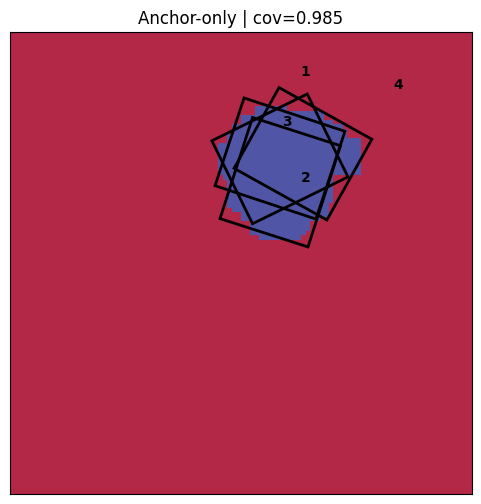

In [165]:
# --- (Optional) quick preview: uncomment to see all four shapes ---
if __name__ == "__main__":
    import numpy as np
    import time

    # Make area
    shapes = [
        ("rectangle", dict(nx=100, ny=100, rect_w=80, rect_h=80)),
        ("l",         dict(nx=100, ny=100)),
        ("y",         dict(nx=100, ny=100)),
        ("random",    dict(nx=100, ny=100, steps=400, seeds=2, seed=13)),
    ]

    # Parameter setting
    # TODO : FOV, line space part are required
    # TODO : MinOnlyBounds should be calculated from the area size and altitude
    # TODO : 'thetas' varibale should be expaned according to the 'num_avs'
    # TODO : box_size could set to be same because to consider a fair share.
    # TODO : altitude seperation 
    num_avs = 4
    thetas = np.zeros(num_avs)  # 박스별 회전 벡터 (초기 0)

    # box rotation constraints
    rot_step = 5.0   # 한 번에 회전할 각도(deg)
    full_rot_every    = 5      # 매 5 iteration마다 전체 앵커 회전 스윕 (0 또는 None이면 비활성)
    rotate_load_cap   = 10     # 회전 평가 최대 개수 상한 (None이면 비활성)
    rotate_sample_frac = 0.5   # 회전 평가할 대상 비율(0<frac≤1). 1.0이면 비활성

    # box size constraints
    size_step = 1.0          # 한 번에 키울 픽셀(셀) 수 (예: 1)
    max_w, max_h = None, None  # 필요하면 상한 지정 (예: nx, ny 등)

    # energy functions parameter
    lam_obs = 0.5
    lam_ov  = 0.0

    altitude = 500  # altitude
    bounds   = MinOnlyBounds(10, 10)  # Bbox minimum size constraints
    target_shape = "random"
    time_limit   = 30  # seconds
    use_sa = True  # ← SA 사용 스위치 (False면 기존 그리디 루프 사용)

    # 선택된 모양 실행
    for name, kw in shapes:
        if name != target_shape:
            continue

        # 1) 영역 생성 & 앵커 샘플링
        nx, ny, obs_pos = generate_region(name, **kw)
        anchors = sample_anchors_in_open_space(
            nx, ny, obs_pos, num_avs=num_avs, min_spacing=None, seed=7
        )

        # 2) 초기 state (LL-앵커, 최소 크기, 회전 0)
        state = make_state_ll(
            anchors, width=bounds.wmin, height=bounds.hmin, thetas_deg=thetas
        )

        # 3) 초기 에너지 (open↑, non-open/overlap↓)
        # E = energy_open_coverage_from_state(nx, ny, obs_pos, state)
        # E = energy_open_vs_obstacle_from_state(nx, ny, obs_pos, state, lam=lam_obs, penalty_norm="covered")
        E = energy_open_obs_overlap_from_state(
            nx, ny, obs_pos, state,
            lam_obs=lam_obs, lam_ov=lam_ov,
            norm_obs="covered", norm_ov="open"
        )
        print(f"[init] score ={1.0 - E:.4f}")

        # temp test ------------------------------------
        # bbox size cap margin
        open_mask = _obs_to_open_mask(nx, ny, obs_pos)
        ys, xs = np.where(open_mask)
        open_w_cap = int(xs.max() - xs.min() + 1)
        open_h_cap = int(ys.max() - ys.min() + 1)

        cap_margin = 1.05  # 5% 여유
        max_w = min(nx, int(open_w_cap * cap_margin))
        max_h = min(ny, int(open_h_cap * cap_margin))
        
        
        if use_sa: # simulated annealing
            # 1) 그리디로 워밍업 (시간 예산의 일부만 사용: 예 30%)
            greedy_frac = 0.10
            greedy_tlim = max(1.0, time_limit * greedy_frac)

            # 필요 변수: num_avs, rot_step, size_step, full_rot_every, rotate_load_cap, rotate_sample_frac, max_w, max_h
            state_g, E_g, t_greedy = greedy_refine(
                nx, ny, obs_pos, state, bounds,
                lam_obs=lam_obs, lam_ov=lam_ov,
                num_avs=num_avs,
                rot_step=rot_step, size_step=size_step,
                max_w=max_w, max_h=max_h,
                patience=50,
                greedy_time_limit=greedy_tlim,
                full_rot_every=full_rot_every,
                rotate_load_cap=rotate_load_cap,
                rotate_sample_frac=rotate_sample_frac
            )
            print(f"[warm-start: greedy] score={1.0 - E_g:.4f}, elapsed={t_greedy:.2f}s")

            # 2) 남은 시간으로 SA 수행
            sa_tlim = max(1.0, time_limit - t_greedy)
            
            cfg = SAConfig(
                T0=0.9, Tmin=1e-3, alpha=0.98,
                p_move=0.6, p_rot=0.3, p_size=0.05,
                step_xy_max=2, step_th_max_deg=10.0, step_sz_max=1,
                gamma_xy=1.0, gamma_th=1.0, gamma_sz=1.0,
                shrink_enable_ratio=0.9,
                neighbor_retry=8,
                outer_rounds=90, inner_loops=200,
                stall_rounds=5, reheats_max=1, reheat_factor=1.5,
                seed=7
            )

            sa_best, sa_best_E, sa_stats = anneal(
                nx, ny, obs_pos, state_g, bounds,
                lam_obs=lam_obs, lam_ov=lam_ov,
                cfg=cfg, time_limit=time_limit,
                max_w=max_w, max_h=max_h, rng_seed=7
            )

            # 카운트 요약
            print("[SA] totals:",
                f"proposed={sa_stats['proposed']}, accepted={sa_stats['accepted']};",
                f"move={sa_stats['move']}/{sa_stats['move_acc']},",
                f"rotate={sa_stats['rotate']}/{sa_stats['rotate_acc']},",
                f"size={sa_stats['size']}/{sa_stats['size_acc']}")

            # === 안전 가드(최종 선택) — 이 줄들로 기존 state,E 할당을 교체 ===
            if sa_best_E < E_g - 1e-12:   # 작은 엡실론으로 동률 처리 안정화
                state, E = sa_best, sa_best_E
                chosen = "SA"
            else:
                state, E = state_g, E_g
                chosen = "Greedy (warm-start)"

            print(f"[select] chosen={chosen}  score={1.0 - E:.4f}")
        else: # greedy search
            # 순수 그리디만 (원래 else 블록을 사용하고 싶다면, 위 greedy_refine를 호출한 뒤 state,E만 반영)
            state, E, _ = greedy_refine(
                nx, ny, obs_pos, state, bounds,
                lam_obs=lam_obs, lam_ov=lam_ov,
                num_avs=num_avs,
                rot_step=rot_step, size_step=size_step,
                max_w=max_w, max_h=max_h,
                patience=50,
                greedy_time_limit=time_limit,
                full_rot_every=full_rot_every,
                rotate_load_cap=rotate_load_cap,
                rotate_sample_frac=rotate_sample_frac
                )

        # 6) 결과 시각화 & 지표 출력
        bboxes_best = bboxes_from_state_ll(state)
        ratio, _ = coverage_ratio_open_space(nx, ny, obs_pos, bboxes_best)
        cb = coverage_breakdown(nx, ny, obs_pos, bboxes_best)
        ob = overlap_breakdown(nx, ny, obs_pos, bboxes_best)
        print(f"open={cb['open_ratio']:.3f}, nonopen_on_cov={cb['nonopen_on_cov']:.3f}, overlap_on_open={ob['overlap_on_open']:.3f}")

        plot_rotated_bboxes(nx, ny, obs_pos, bboxes_best, f"Anchor-only | cov={ratio:.3f}")
        break  # target_shape 하나만 실행
